# **Breast cancer image analysis by using Convolutional Neural Network.**

Word count: 1980 (with comparison table)

Name: Kivindu Prageeth Bandara Attanayake

Student ID: W24043390

#Table of contents.

#EDA analysis.  
*   Dataset analysis
*   Images analysis
*   Class imbalance analysis
*   Image size analysis
*   Pixel distribution analysis
*   EDA summary

# Data pre-process.
*   Splitting the data
*   Data augmenting
*   Normalisation

# Model design, training and fine-tuning.

*   Proposed architecture

  *   Conv2D
  *   Subsampling
  *   Flatten
  *   Dense
  *   Dropout
  *   Features
  *   Kernal, Padding and Stride
  *   Rectified linear unit
  *   Sigmoid
  *   ADAM
  *   BinaryCrossentropy
  *   Epoch
  *   Batch size

*   Hyperparameter Tune
*   Logistic regression


# Evaluation and comparison.

* Initial model.
  *   Loss
  *   Accuracy
  *   ROC AUC
  *   Confusion matrix

* Hyperparameters
  *   Hyperparameters best result
  *   Hyperparameter model’s loss and accuracy
  *   Loss
  *   Accuracy
  *   ROC AUC
  *   Confusion matrix for unseen data

* Logistic Regression for unseen data

* Comparison

# Conclusion.

# References.





















#EDA analysis.

### Dataset analysis

Multi-dimensional array with 5547 labels and images with 50x50 pixels and RGB channels. N1xN2xCin, where the Cin is the number of input channels and, if RGB colors, then Cin=3 (Raschka and Mirjalili, 2019, p.532). Label is a single dimensional array. Labels count and images are equal. Labels are stored as 0 and 1 with two classes and can be categorised as a binary classification problem. 0 is IDC negative and 1 is IDC positive.


### Images analysis

Assumption: All the labels are correct with images. Images have different kinds of patterns with various colors, it helps to extract more features, and it will lead to making the decision more precious (Suh et al., 2022).

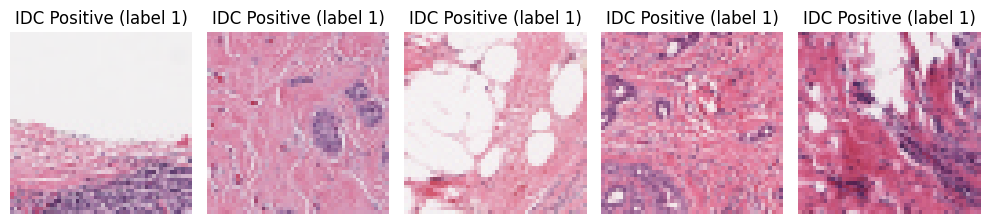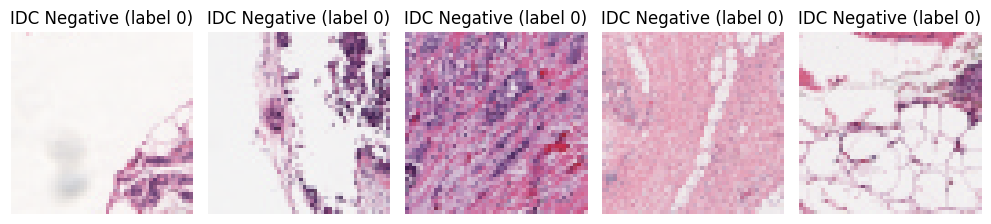


### Class imbalance analysis

Label 0=49.7%, 1= 53.3%. The difference is only 29 images. There is no class imbalance, and they will contain the same class distribution as the dataset after splitting. Data imbalance is a challenge for effective training and evaluation (Park et al., 2025).

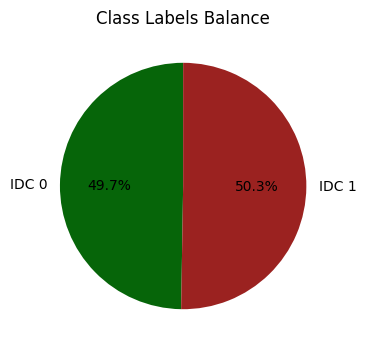

### Image size analysis

All images are resized for 50x50 pixels. Raschka and Mirjalili (2019, p.557) resized all their augmented images into 64 x 64 to keep consistent and error free to match with their input layer during model training.  


### Pixel distribution analysis

Pixel values are not distributed normally for all images. These images are normalized between 0 and 1 distribution. Because the gradient base optimization is more stable under this condition (Raschka and Mirjalili, 2019, p.396).
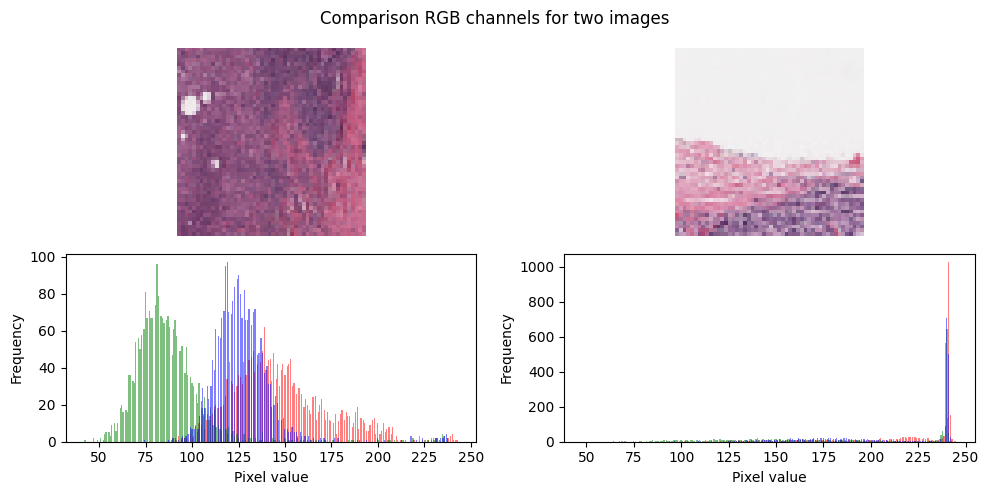
### EDA summary

This is a binary classification problem based on images. Classes are balanced. The Convolutional Neural Network (CNN) can be used to extract features. The problem which is going to be sorted out is “Breast cancer image analysis by using Convolutional Neural Network and predict for unseen data whether the IDC (invasive ductal carcinoma) positive or negative”.

In [ ]:
# Exploratory data analysis for breast cancer images

# About dataset from the source

# 5547 breast histology images
# 5547 labels 0=(IDC -), 1=(IDC +)
# Image size 50 x 50 x 3 (RGB)
# Two numpy arrays  called X(images) and Y(labeles)

# Import data
from google.colab import drive
import numpy as np
import pandas as pd

# Connect to the Google drive to access the dataset.
drive.mount('/content/drive')

# Load the dataset
X_original_images = np.load('/content/drive/MyDrive/Machine learning/Individual assignment/X.npy')
y_original_labels = np.load('/content/drive/MyDrive/Machine learning/Individual assignment/Y.npy')





Mounted at /content/drive


In [ ]:
# Exploratory data analysis for breast cancer images continue.

# Print the shape of the dataset to get idea
print(X_original_images.shape)
print(y_original_labels.shape)

(5547, 50, 50, 3)
(5547,)


[ 608 1660 2331 1643 2440]
[5180 4422 3954 5469 2822]


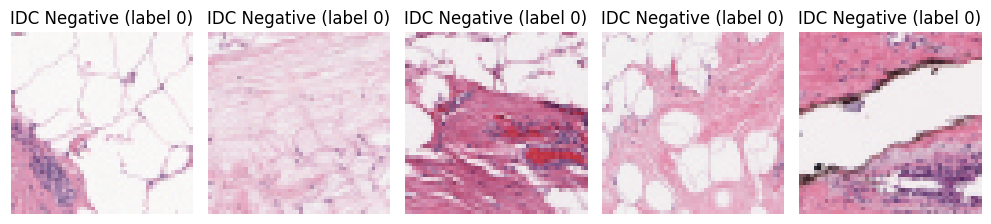

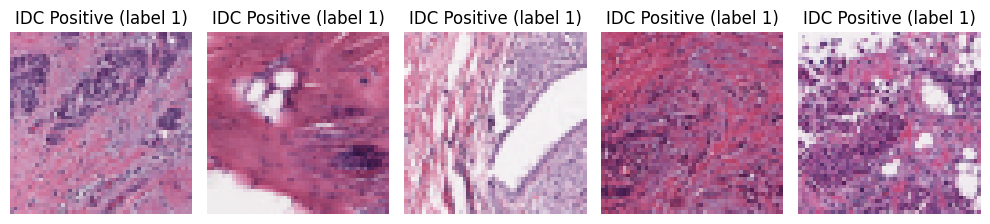

In [ ]:
# Exploratory data analysis for breast cancer images continue.

# Check random images per class (5 images) with their labels using plot.
import matplotlib.pyplot as plt

random_images_idc_negative = np.random.choice(np.where(y_original_labels == 0)[0],5)
random_images_idc_positive = np.random.choice(np.where(y_original_labels == 1)[0],5)

print(random_images_idc_negative)
print(random_images_idc_positive)

# Plot IDC Negative images separately
fig, axes = plt.subplots(1,5, figsize=(10,5))
for i, index in enumerate(random_images_idc_negative):
  axes[i].imshow(X_original_images[index])
  axes[i].set_title('IDC Negative (label 0)')
  axes[i].axis('off')
plt.tight_layout()
plt.show()

# Plot IDC Positive imgaes separately
fig, axes = plt.subplots(1,5, figsize=(10,5))
for i, index in enumerate(random_images_idc_positive):
  axes[i].imshow(X_original_images[index])
  axes[i].set_title('IDC Positive (label 1)')
  axes[i].axis('off')
plt.tight_layout()
plt.show()



Number of zero labels :2759
Number of one labels :2788
True


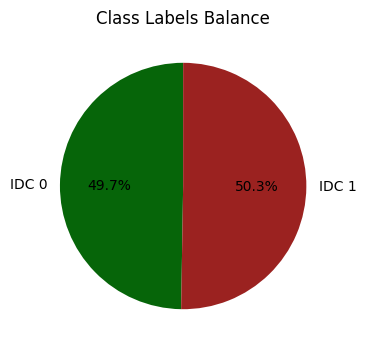

In [ ]:
# Exploratory data analysis for breast cancer images continue.

# Class (labels) imbalnce check
label_zero_count = np.count_nonzero(y_original_labels == 0)
label_one_count = np.count_nonzero(y_original_labels == 1)

print(f'Number of zero labels :{label_zero_count}')
print(f'Number of one labels :{label_one_count}')
print(label_zero_count + label_one_count == len(y_original_labels) )

# Create pie chart for label count
labels = ["IDC 0", "IDC 1"]
sizes = [label_zero_count, label_one_count]
colors = ["#066509", "#9b2220"]
plt.figure(figsize=(4, 4))
plt.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
plt.title("Class Labels Balance")
plt.show()


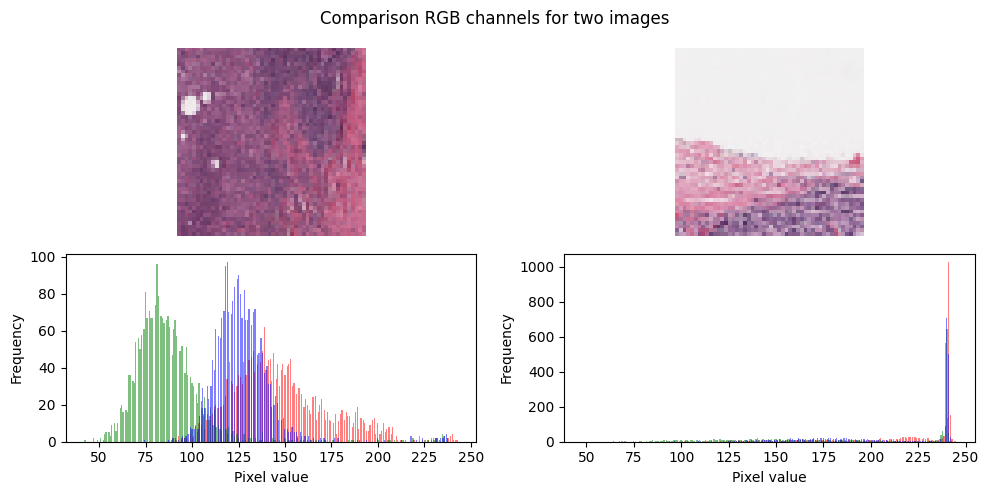

In [ ]:
# Exploratory data analysis for breast cancer images continue.

# Color channels\pixel imbalance

# Plot selected images with different color for index:1215,5460
image_1 = X_original_images[1215]
image_2 = X_original_images[5460]

#Get RGB color channels
im1_red = image_1[:,:,0]
im1_green = image_1[:,:,1]
im1_blue = image_1[:,:,2]
im2_red = image_2[:,:,0]
im2_green = image_2[:,:,1]
im2_blue = image_2[:,:,2]

fig, axes = plt.subplots(2,2, figsize=(10,5))
axes[0,0].imshow(image_1)
axes[0,0].axis('off')
axes[0,1].imshow(image_2)
axes[0,1].axis('off')
axes[1,0].hist(im1_red.ravel(), bins=256, color='red', alpha=0.5)
axes[1,0].hist(im1_green.ravel(), bins=256, color='green', alpha=0.5)
axes[1,0].hist(im1_blue.ravel(), bins=256, color='blue', alpha=0.5)
axes[1,0].set_xlabel('Pixel value')
axes[1,0].set_ylabel('Frequency')
axes[1,1].hist(im2_red.ravel(), bins=256, color='red', alpha=0.5)
axes[1,1].hist(im2_green.ravel(), bins=256, color='green', alpha=0.5)
axes[1,1].hist(im2_blue.ravel(), bins=256, color='blue', alpha=0.5)
axes[1,1].set_xlabel('Pixel value')
axes[1,1].set_ylabel('Frequency')
plt.suptitle('Comparison RGB channels for two images')
plt.tight_layout()
plt.show()

# Data pre-process

### Splitting the data

“We will only apply data augmentation to the training examples, however, and not to the validation or test images” (Raschka and Mirjalili, 2019, p.557). The holdout method with 20% test(unseen) and 80% training(remain) was used. Training set augmented due to lack of dataset. For hyperparameter process, holdout method used for the first 80% training set to create small portions with 80% as training. Original unseen data used for both initial model and hyperparameter model tests.

### Data augmenting

5547 images were not enough to train a robust model and will lead to overfitting. To improve the model genralisation performance and to reduce the overfitting, the data augmentation was processed. Flipping, adjusting the contrast and the brightness are used (Raschka and Mirjalili, 2019, p.550-552). Cropping images technique avoided because it will remove the essential features.
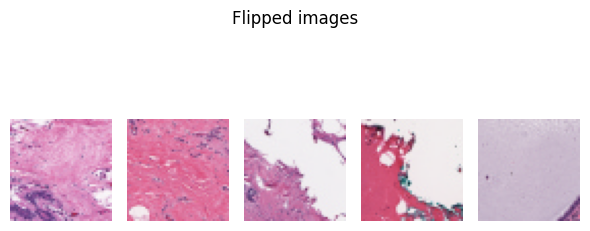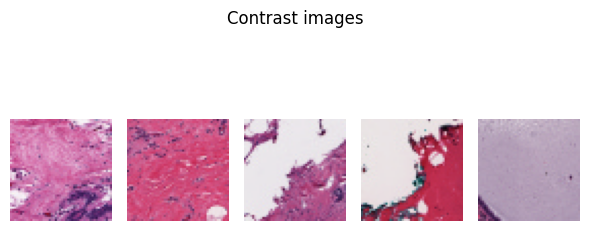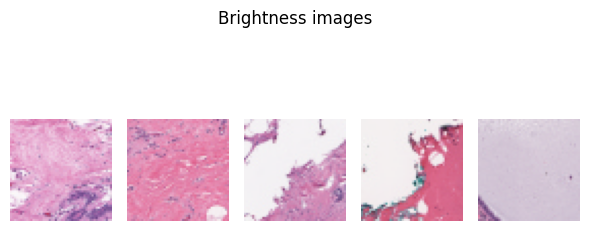

### Normalisation  

Pixel distribution varies between 0-255 (Raschka and Mirjalili, 2019, p.533) and the majority of machine learning and optimisation algorithms work well if the features are with the same scale and min-max scaling technique used to normalise the above range to [0,1] (Raschka and Mirjalili, 2019, p.124-125). No need to one-hot encode labels because they are 0 and 1. This normalisation also helps to keep the gradient stability.

In [ ]:
# Data pre-process, prepare and model generalisation

# Splitting train and test data using holdout method
from sklearn.model_selection import train_test_split

X_remain_images, X_unseen_images, y_remain_labels, y_unseen_labels = train_test_split(X_original_images, y_original_labels, test_size=0.2, random_state=40)

# Verify the number of dataset
print('X_original_images', X_original_images.shape)
print('y_original_labels', y_original_labels.shape)
print('X_unseen_images', X_unseen_images.shape)
print('y_unseen_labels', y_unseen_labels.shape)
print('X_remain_images', X_remain_images.shape)
print('y_remain_labels', y_remain_labels.shape)


X_original_images (5547, 50, 50, 3)
y_original_labels (5547,)
X_unseen_images (1110, 50, 50, 3)
y_unseen_labels (1110,)
X_remain_images (4437, 50, 50, 3)
y_remain_labels (4437,)


X_flipped_images (4437, 50, 50, 3)
y_flipped_labels (4437,)


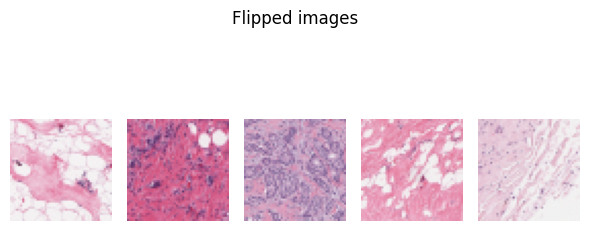

In [ ]:
# Data pre-process, prepare and model generalisation continue

# Data augmenting: flip horizontally
X_flipped_images = []
y_flipped_labels = []

for i in range(X_remain_images.shape[0]):
  X_flipped_images.append(np.fliplr(X_remain_images[i]))
  y_flipped_labels.append(y_remain_labels[i])

# Convert back to numpy arrays
X_flipped_images = np.array(X_flipped_images)
y_flipped_labels = np.array(y_flipped_labels)

# Verify the dataset
print('X_flipped_images', X_flipped_images.shape)
print('y_flipped_labels', y_flipped_labels.shape)

# Plot random sample images
fig, axes = plt.subplots(1,5, figsize=(6,3))
for i, index in enumerate([0,100,250,500,1000]):
  axes[i].imshow(X_flipped_images[index])
  axes[i].axis('off')
plt.suptitle('Flipped images')
plt.tight_layout()
plt.show()


X_contrast_images (4437, 50, 50, 3)
y_contrast_labels (4437,)


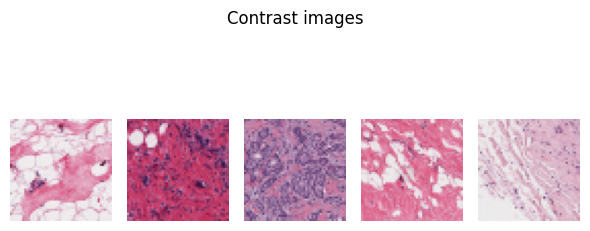

In [ ]:
# Data pre-process, prepare and model generalisation continue

# Data augmenting: adjusting the contrast
# To increase contrast, need to change gamma value more than 1.
from skimage.exposure import adjust_gamma

X_contrast_images = []
y_contrast_labels = []

for i in range(X_remain_images.shape[0]):
  X_contrast_images.append(adjust_gamma(X_remain_images[i], gamma = 1.5))
  y_contrast_labels.append(y_remain_labels[i])

# Convert back to numpy arrays
X_contrast_images = np.array(X_contrast_images)
y_contrast_labels = np.array(y_contrast_labels)

# Verify the dataset
print('X_contrast_images', X_contrast_images.shape)
print('y_contrast_labels', y_contrast_labels.shape)

# Plot random sample images
fig, axes = plt.subplots(1,5, figsize=(6,3))
for i, index in enumerate([0,100,250,500,1000]):
  axes[i].imshow(X_contrast_images[index])
  axes[i].axis('off')
plt.suptitle('Contrast images')
plt.tight_layout()
plt.show()


X_brightness_images (4437, 50, 50, 3)
y_brightness_labels (4437,)


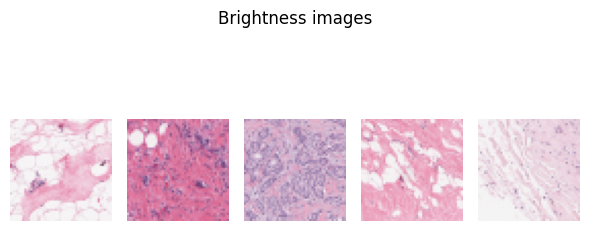

In [ ]:
# Data pre-process, prepare and model generalisation continue

# Data augmenting: adjusting the brightness
# Contrast and brightness using same funtion 'adjust_gamma'.
# Here we use to dark the images by using gamme value less than 1

X_brightness_images = []
y_brightness_labels = []

for i in range(X_remain_images.shape[0]):
  X_brightness_images.append(adjust_gamma(X_remain_images[i], gamma = 0.8 ))
  y_brightness_labels.append(y_remain_labels[i])

# Convert back to numpy arrays
X_brightness_images = np.array(X_brightness_images)
y_brightness_labels = np.array(y_brightness_labels)

# Verify the dataset
print('X_brightness_images', X_brightness_images.shape)
print('y_brightness_labels', y_brightness_labels.shape)

# Plot random sample images
fig, axes = plt.subplots(1,5, figsize=(6,3))
for i, index in enumerate([0,100,250,500,1000]):
  axes[i].imshow(X_brightness_images[index])
  axes[i].axis('off')
plt.suptitle('Brightness images')
plt.tight_layout()
plt.show()

In [ ]:
# Data pre-process, prepare and model generalisation continue

# Combine all augmented data set with remain dataset.
X_combined_images = np.concatenate([X_remain_images, X_flipped_images, X_contrast_images, X_brightness_images], axis=0)
y_combined_labels = np.concatenate([y_remain_labels, y_flipped_labels, y_contrast_labels, y_brightness_labels], axis=0)

# Verify dataset
print('X_combined_images', X_combined_images.shape)
print('y_combined_labels', y_combined_labels.shape)

X_combined_images (17748, 50, 50, 3)
y_combined_labels (17748,)


In [ ]:
# Data pre-process, prepare and model generalisation continue

# Data Normalisation using min-max scaling technique, max=256, min=0
X_normalised_images = X_combined_images.astype('float32') / 255.0
X_unseen_images = X_unseen_images.astype('float32') / 255.0

# Labels no need to one-hot encode because they are 0 and 1 which is only two classes.
# But normalised labels array created for a keep name convention properly.
y_normalised_labels = y_combined_labels



# Verify dataset
print('X_normalised_images', X_normalised_images.shape)
print('X_unseen_images', X_unseen_images.shape)
print('y_normalised_labels', y_normalised_labels.shape)
print('y_unseen_labels', y_unseen_labels.shape)


X_normalised_images (17748, 50, 50, 3)
X_unseen_images (1110, 50, 50, 3)
y_normalised_labels (17748,)
y_unseen_labels (1110,)


#Model design, training and fine-tuning

The architecture was built from scratch to achieve changing layers, activation, and parameters. Pretrained models may not be perfect to solve specific problem and not flexible and less competitive (Moudden and Amnai, 2023).

## Proposed architecture

CNN learns features automatically from raw data. CNN performs excellent in image classification because of its two specific characteristics which are “Sparse connectivity” and “Parameter-sharing” and combined with several convolutional and subsampling layers with fully connected MLP layer. Keres Sequential class used to stack convolution, pooling, dropout and dense layers (Raschka and Mirjalili, 2019, pp.519-520, 545).

### Conv2D:

*   Three Conv2D layers with 32,64 and 128 and (3x3) kernal, stride=1 and same padding used.

When the input has matrix then convolution in 2D used. Conv2D is a convolution layer from ‘Keras’ with configurable parameters. The input dimension is (17748,50,50,3) and automatically detects that input is NHWC format. (Raschka and Mirjalili, 2019, pp.545-546).

### Subsampling:

*   Three MaxPool2D layers after every Conv2D with stride=2 and window size 2x2 used.

Subsampling is typically included in CNNs in two forms max and mean pooling and decreases the size of features which leverage to reduce overfitting and to achieve higher computational efficiency. The traditional way is to set strider same as the pooling parameter to keep overlapping (Raschka and Mirjalili, 2019, p. 530-531).

### Flatten:

Connected to the dense layer. CNN layers give height, width, channels shape output and should be flattened because dense input is (batch size x input units). Flattening data will be suitable for input to the fully connected layer (Naz Dündar et al., 2024).


### Dense:

* First dense layers with 512 filters and the last layer with 1.

Added to the end of the convolutional and pooling layers to get a final class prediction with Sigmoid (Raschka and Mirjalili, 2019, p. 546–547). Challenge: the first dense layer filters should be lower than flatten layer output but I'm not sure how many filters to use.

### Dropout:

* Dropout layer with 0.5 probability.

Used to higher layers, and it is dropping fraction of hidden using probability and lead to force the network to learn from redundant representation of data which is also helps to decrease overfitting. Challenge: I'm not sure where to add the dropout layer, since Raschka and Mirjalili (2019, pp. 537–538, 547) proceed with dropout layer between dense layer and I followed that.

### Features:

* Features 32,64 and 128 are used.

Feature maps follow incremental patterns according to CNN's hierarchical stacking behavior. Low levels extract low level patterns and deeper layers capture complex patterns (Raschka and Mirjalili, 2019, p.559).


### Kernal, Padding Stride:



* To keep the dimensional spatial same as input, default stride=1 and padding=same with 3x3 kernel were selected.

Output Size = [(input size + 2xPadding - Kernal size) / Stride] + 1, the kernel, padding and stride are directly affecting the output size. CNNs commonly use 1x1,3x3, or 5x5 to reduce computation power and to gain efficiency and most used padding is the same padding, and it preserves the size (Raschka and Mirjalili, 2019, p.524-530). 5x5 is used for large input sizes and 3 x 3 is the most suitable size for 50x50 pixel images.


### Rectified linear unit:

ReLU can reduce the vanishing gradient problem which other activations have. This keeps gradients for positive input values, and easy to optimise(Goodfellow, Bengio and Courville, 2016, p. 193).

### Sigmoid:

A logistic function that activation gives 0 and 1 as binary classification (Raschka and Mirjalili, 2019, p.463). Therefore, in the last dense layer the sigmoid is used to classify the two classes.


### ADAM:

Stochastic gradient optimization and a robust method. Highly efficient and has little memory requirement which is leverage the computational efficiency (tensorflow, 2020).  

### BinaryCrossentropy:

Raschka and Mirjalili clearly argued that the best loss function to the binary classification is BinaryCrossentropy (2019, p. 539).

### Epoch:

Early stopping implemented and initially 75 epochs used to get optimal weights without wasting computational power and overfitting.  

### Batch size:

There is no specific number for batch size but for the training 64 value is used.

### Hyperparameter Tune

Focused on number of filters, activations, optimizer and batch size. ‘Remain’ dataset was used which is 80% from the original data for allocating small samples to gain faster iterations, computational efficiency and to prevent overfitting.

Filters are varied from 32 to 128 with 32 increments. Activation choices are ‘relu’ and ‘sigmoid’. The dense layer’s filters were set 128 to 512. The learning rate was set to 0.001, or 0.0001 and the optimizer is ‘adam’ or ‘sgd’. Batch size tuned between 16,32, and 64.

### Logistic regression

* Max_iter=10000, solver=saga.

Logistic regression used with the same train and test dataset. “Saga” used because it is faster than ‘lbfgs’ (scikit-learn, 2025).

In [ ]:
# Define method for create model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D

# According to the report architecure the model is implemented.
# Architecure with parameters are described in the report.

def create_model():
  model = Sequential()
  model.add(Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu', input_shape = (50,50,3), padding = 'same', name = 'conv2d_1'))
  model.add(MaxPooling2D((2,2), name = 'pooling_1'))
  model.add(Conv2D(filters = 64, kernel_size = (3,3), activation = 'relu', padding = 'same', name = 'conv2d_2'))
  model.add(MaxPooling2D((2,2), name = 'pooling_2'))
  model.add(Conv2D(filters = 128, kernel_size = (3,3), activation = 'relu', padding = 'same', name = 'conv2d_3'))
  model.add(MaxPooling2D((2,2), name = 'pooling_3'))
  model.add(Flatten(name = 'flatten_1'))
  model.add(Dense(units = 512, activation = 'relu', name  = 'dense_1'))
  model.add(Dropout(0.5, name = 'dropout_1'))
  model.add(Dense(units = 1, activation = 'sigmoid', name = 'dense_2'))
  model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
  return model

In [ ]:
# Implement early stopping epoches
from tensorflow.keras.callbacks import EarlyStopping

# Patience 3 means it wait 3 epochs to loss to improve before stop.
# After stop, current weights restore by the best weights values.
epoch_stop = EarlyStopping(monitor = 'loss', patience = 3, restore_best_weights = True)

# Train initial model
model = create_model()
hist = model.fit(X_normalised_images, y_normalised_labels, epochs = 75, batch_size=64, verbose=1, callbacks=[epoch_stop], validation_split=0.2)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/75
222/222 ━━━━━━━━━━━━━━━━━━━━ 79s 350ms/step - accuracy: 0.6322 - loss: 0.6374 - val_accuracy: 0.6969 - val_loss: 0.5904
Epoch 2/75
222/222 ━━━━━━━━━━━━━━━━━━━━ 81s 343ms/step - accuracy: 0.7461 - loss: 0.5365 - val_accuracy: 0.7377 - val_loss: 0.5415
Epoch 3/75
222/222 ━━━━━━━━━━━━━━━━━━━━ 81s 338ms/step - accuracy: 0.7587 - loss: 0.5171 - val_accuracy: 0.7670 - val_loss: 0.4881
Epoch 4/75
222/222 ━━━━━━━━━━━━━━━━━━━━ 82s 341ms/step - accuracy: 0.7588 - loss: 0.5120 - val_accuracy: 0.7501 - val_loss: 0.4978
Epoch 5/75
222/222 ━━━━━━━━━━━━━━━━━━━━ 82s 341ms/step - accuracy: 0.7665 - loss: 0.4960 - val_accuracy: 0.7865 - val_loss: 0.4664
Epoch 6/75
222/222 ━━━━━━━━━━━━━━━━━━━━ 84s 349ms/step - accuracy: 0.7787 - loss: 0.4850 - val_accuracy: 0.7859 - val_loss: 0.4637
Epoch 7/75
222/222 ━━━━━━━━━━━━━━━━━━━━ 85s 361ms/step - accuracy: 0.7896 - loss: 0.4622 - val_accuracy: 0.7823 - val_loss: 0.4732
Epoch 8/75
222/222 ━━━━━━━━━━━━━━━━━━━━ 81s 364ms/step - accuracy: 0.7955 - loss: 0

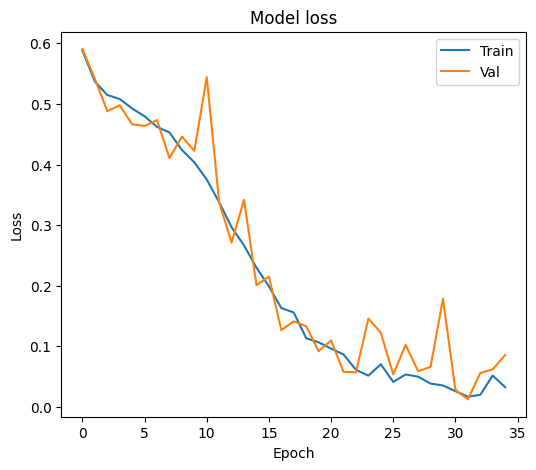

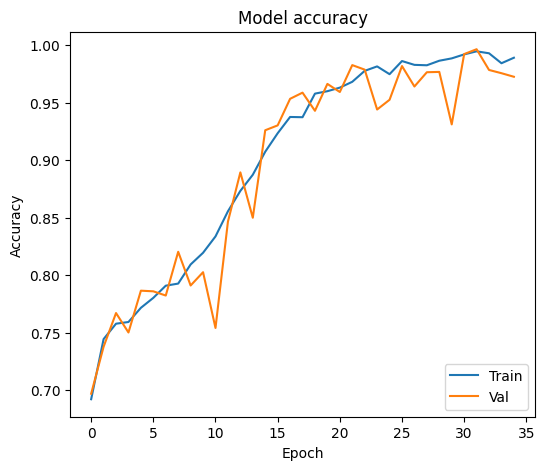

In [ ]:
# Training and validation curves against epoch
import matplotlib.pyplot as plt

# Model loss
plt.figure(figsize=(6, 5))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

# Model accuracy
plt.figure(figsize=(6, 5))
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [ ]:
# Predication using initial model agains unseen data
y_pred = model.predict(X_unseen_images)

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step


In [ ]:
# Calculate Area Under the Curve

from sklearn.metrics import roc_auc_score

# Creating probablity from no skill model (which is not trained by anthing)
# Making 0 values array with length of unseen labels

noskill_probs = [0 for _ in range(len(y_unseen_labels))]

# Calculate the area of curve under the ROC agains no skill model and initial model
# AUC for no skill and predictions are calculated using unseen data
noskill_auc = roc_auc_score(y_unseen_labels, noskill_probs)
initial_auc = roc_auc_score(y_unseen_labels, y_pred)

# Calculated AUC
print('No skill: ROC AUC=%.3f' % (noskill_auc))
print('Initial model: ROC AUC=%.3f' % (initial_auc))

No skill: ROC AUC=0.500
Initial model: ROC AUC=0.788


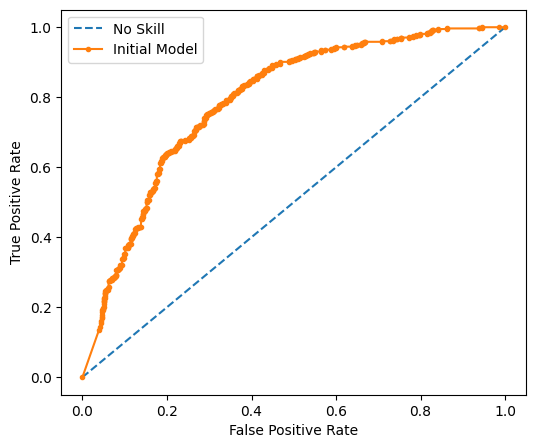

In [ ]:
# Plotting Receiver Operating Characteristic (ROC) curve
# ROC use for show classification models true positive rate against false positive rate

from sklearn.metrics import roc_curve

# This roc_curve returns three values and we only need two of them
# False positive rate at different thresholds for the model
# True positive value rate at different thresholds for the model
noskill_fpr, noskill_tpr, _ = roc_curve(y_unseen_labels, noskill_probs)
initial_fpr, initial_tpr, _ = roc_curve(y_unseen_labels, y_pred)

# Plotting the ROC
plt.figure(figsize=(6, 5))
plt.plot(noskill_fpr, noskill_tpr, linestyle='--', label='No Skill')
plt.plot(initial_fpr, initial_tpr, marker='.', label='Initial Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


Initial model confusion matrix:
[[374 160]
 [143 433]]


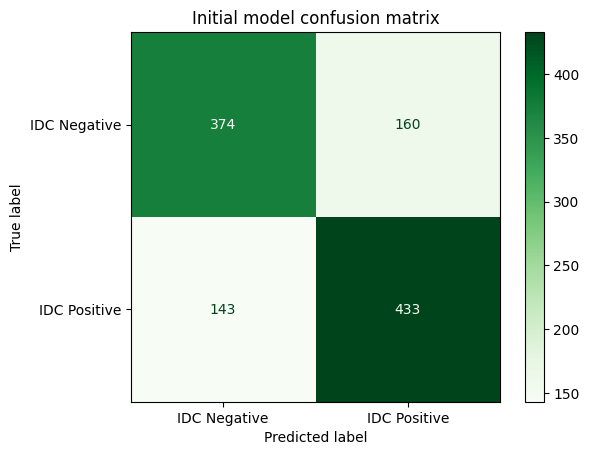

In [ ]:
# Compute the confusion matrix.

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# If probability is higer than 0.5 then its class 1 , otherwise class 0
y_pred_binary = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_unseen_labels, y_pred_binary)

print("Initial model confusion matrix:")
print(cm)

# Plot confusion matrix
display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['IDC Negative', 'IDC Positive'])
display.plot(cmap = 'Greens')
plt.title('Initial model confusion matrix')
plt.show()



In [ ]:
# Create hyperparameter tuning

# Used "remain" traning (80%) dataset from original data to keep data sample small
# To improve computational effciency
# Faster iteration
# To prevent over fitting
# Mainly focusing on tuning number of filters, activation, learning rate, optimizer, batch size

# Normalize "remain" dataset
X_remain_normalized_images = X_remain_images.astype('float32') / 255.0

# Verify dataset
print('X_remain_normalized_images', X_remain_normalized_images.shape)


X_remain_normalized_images (4437, 50, 50, 3)


In [ ]:
!pip install keras-tuner
!pip install scikeras
import keras_tuner as kt
from tensorflow.keras import optimizers


# Create hyperparamter model
def model_builder_hp(hp):
    model = Sequential()

    # First Conv2D
    # Tune first Conv2D layer with number of filters between 32-128 with 32 increment
    conv2d_1_filters = hp.Int('conv2d_1_filters', min_value=32, max_value=128, step=32)
    # Tune activation function between relu and sigmoid
    conv2d_1_activation = hp.Choice('conv2d_1_activation', values=['relu', 'sigmoid'])
    model.add(Conv2D(filters = conv2d_1_filters, kernel_size = (3,3), activation = conv2d_1_activation, input_shape = (50,50,3), padding = 'same', name = 'conv2d_1'))

    # Keep pooling layer as it is
    model.add(MaxPooling2D((2,2), name = 'pooling_1'))

    # Second Conv2D
    # Tune second Conv2D layer with number of filters between 32-128 with 32 increment
    conv2d_2_filters = hp.Int('conv2d_2_filters', min_value=32, max_value=128, step=32)
    # Tune activation function between relu and sigmoid
    conv2d_2_activation = hp.Choice('conv2d_2_activation', values=['relu', 'sigmoid'])
    model.add(Conv2D(filters = conv2d_2_filters, kernel_size = (3,3), activation = conv2d_2_activation, padding = 'same', name = 'conv2d_2'))

    # Keep pooling layer as it is
    model.add(MaxPooling2D((2,2), name = 'pooling_2'))

    # Third Conv2D
    # Tune third Conv2D layer with number of filters between 32-128 with 32 increment
    conv2d_3_filters = hp.Int('conv2d_3_filters', min_value=32, max_value=128, step=32)
    # Tune activation function between relu and sigmoid
    conv2d_3_activation = hp.Choice('conv2d_3_activation', values=['relu', 'sigmoid'])
    model.add(Conv2D(filters = conv2d_3_filters, kernel_size = (3,3), activation = conv2d_3_activation, padding = 'same', name = 'conv2d_3'))

    # Keep pooling layer as it is
    model.add(MaxPooling2D((2,2), name = 'pooling_3'))

    # Keep flattern layer as it is
    model.add(Flatten(name = 'flatten_1'))

    # First dense layer
    dense_1_units = hp.Int('dense_1_units', min_value = 128, max_value = 512, step = 128)
    dense_1_activation = hp.Choice('dense_1_activation', values=['relu', 'sigmoid'])
    model.add(Dense(units = dense_1_units, activation = dense_1_activation, name  = 'dense_1'))

    # Keep the drop layer as it is
    model.add(Dropout(0.5, name = 'dropout_1'))

    # Keep the last dense layer as it is
    model.add(Dense(1, activation = 'sigmoid', name = 'dense_2'))

    # Tune learning rate for 0.001, or 0.0001
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3])

    # Tune optimizer btween adam and sgd
    tune_optimizer = hp.Choice('optimizer', values=['adam', 'sgd'])
    if tune_optimizer == 'adam':
        optimizer = optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = optimizers.SGD(learning_rate=learning_rate)

    # Tune batch sizes between 16, 32 and 64
    tune_batch_size = hp.Choice('batch_size', values=[16, 32, 64])

    # Compile model with the hyperparameters
    model.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])

    return model



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 10.8 MB/s eta 0:00:00


In [ ]:
# Create tuner object with the configurations

# val_accuracy used to maximise the validation accurary of the model
# Maximum epoch number is 10 for each dataset
# Factor 3 is the how the rate of reducing the configuration from the tuner
tuner = kt.Hyperband(model_builder_hp, objective='val_accuracy', max_epochs=10, factor=3)

# Perform the hyperparameter search with tune batch size.
# Initial number of epochs is 15
tuner.search(X_remain_normalized_images, y_remain_labels , epochs = 15, validation_split = 0.2)

# Fetch the best hyperparameters
# 1 st trail is the top(best) performing trail
hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(hyperparameters.values)

# Output
# Trial 30 Complete [00h 06m 44s]
# val_accuracy: 0.5067567825317383

# Best val_accuracy So Far: 0.7657657861709595
# Total elapsed time: 01h 16m 47s
# {'conv2d_1_filters': 64, 'conv2d_1_activation': 'relu', 'conv2d_2_filters': 32, 'conv2d_2_activation': 'relu', 'conv2d_3_filters': 128, 'conv2d_3_activation': 'relu', 'dense_1_units': 384, 'dense_1_activation': 'sigmoid', 'learning_rate': 0.001, 'optimizer': 'adam', 'batch_size': 32, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}

Trial 30 Complete [00h 06m 44s]
val_accuracy: 0.5067567825317383

Best val_accuracy So Far: 0.7657657861709595
Total elapsed time: 01h 16m 47s
{'conv2d_1_filters': 64, 'conv2d_1_activation': 'relu', 'conv2d_2_filters': 32, 'conv2d_2_activation': 'relu', 'conv2d_3_filters': 128, 'conv2d_3_activation': 'relu', 'dense_1_units': 384, 'dense_1_activation': 'sigmoid', 'learning_rate': 0.001, 'optimizer': 'adam', 'batch_size': 32, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}


In [ ]:
# Train initial model with best hyperprameters
model_hyperparameter = model_builder_hp(hyperparameters)
hist_best_param = model_hyperparameter.fit(X_normalised_images, y_normalised_labels, epochs = hyperparameters.get('tuner/epochs'), batch_size = hyperparameters.get('batch_size'), validation_split=0.2)


Epoch 1/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 86s 190ms/step - accuracy: 0.6251 - loss: 0.6593 - val_accuracy: 0.6963 - val_loss: 0.5804
Epoch 2/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 141s 189ms/step - accuracy: 0.7397 - loss: 0.5441 - val_accuracy: 0.6890 - val_loss: 0.6021
Epoch 3/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 83s 186ms/step - accuracy: 0.7492 - loss: 0.5243 - val_accuracy: 0.7262 - val_loss: 0.5392
Epoch 4/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 139s 181ms/step - accuracy: 0.7537 - loss: 0.5216 - val_accuracy: 0.7515 - val_loss: 0.5156
Epoch 5/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 84s 184ms/step - accuracy: 0.7669 - loss: 0.4935 - val_accuracy: 0.7485 - val_loss: 0.5115
Epoch 6/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 82s 185ms/step - accuracy: 0.7641 - loss: 0.4998 - val_accuracy: 0.7606 - val_loss: 0.5148
Epoch 7/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 141s 184ms/step - accuracy: 0.7703 - loss: 0.4990 - val_accuracy: 0.7659 - val_loss: 0.4965
Epoch 8/10
444/444 ━━━━━━━━━━━━━━━━━━━━ 82s 183ms/step - accuracy: 0.7841 - loss

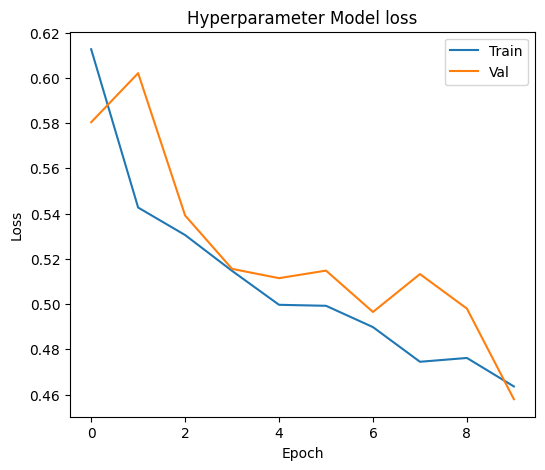

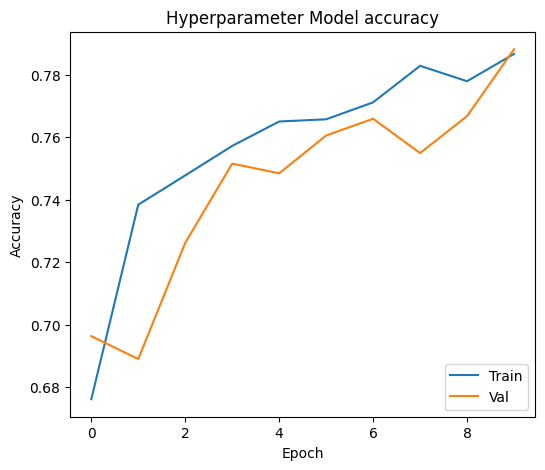

In [ ]:
# Training and validation curves against epoch
import matplotlib.pyplot as plt

# Hyperparameter Model loss
plt.figure(figsize=(6, 5))
plt.plot(hist_best_param.history['loss'])
plt.plot(hist_best_param.history['val_loss'])
plt.title('Hyperparameter Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

# Hyperparameter Model accuracy
plt.figure(figsize=(6, 5))
plt.plot(hist_best_param.history['accuracy'])
plt.plot(hist_best_param.history['val_accuracy'])
plt.title('Hyperparameter Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [ ]:
# Predication using hyperparameter model agains unseen data
y_pred_hyperparameter = model_hyperparameter.predict(X_unseen_images)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [ ]:
# Calculate Area Under the Curve for hyperparameter

from sklearn.metrics import roc_auc_score

# Creating probablity from no skill model (which is not trained by anthing)
# Making 0 values array with length of unseen labels

noskill_probs = [0 for _ in range(len(y_unseen_labels))]

# Calculate the area of curve under the ROC agains no skill model and hyperparameter model
# AUC for no skill and predictions are calculated using unseen data
noskill_auc = roc_auc_score(y_unseen_labels, noskill_probs)
hyperparameter_auc = roc_auc_score(y_unseen_labels, y_pred_hyperparameter)

# Calculated AUC
print('No skill: ROC AUC=%.3f' % (noskill_auc))
print('Hyperparameter model: ROC AUC=%.3f' % (hyperparameter_auc))

No skill: ROC AUC=0.500
Hyperparameter model: ROC AUC=0.850


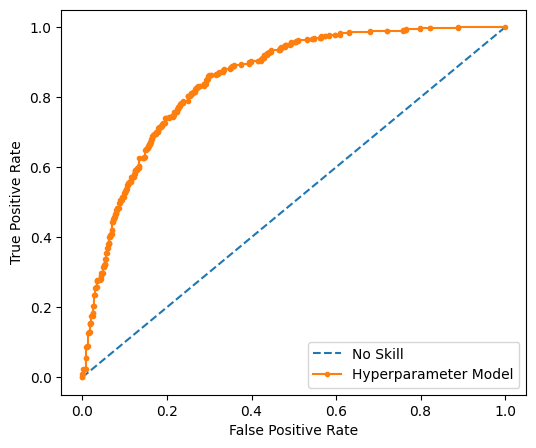

In [ ]:
# Plotting Receiver Operating Characteristic (ROC) curve
# ROC use for show classification models true positive rate agains false positive rate

from sklearn.metrics import roc_curve

# This roc_curve returns three values and we only need two of them
# False positive rate at different thresholds for the model
# True positive value rate at different thresholds for the model
noskill_fpr, noskill_tpr, _ = roc_curve(y_unseen_labels, noskill_probs)
hyperparameter_fpr, hyperparameter_tpr, _ = roc_curve(y_unseen_labels, y_pred_hyperparameter)

# Plotting the ROC
plt.figure(figsize=(6, 5))
plt.plot(noskill_fpr, noskill_tpr, linestyle='--', label='No Skill')
plt.plot(hyperparameter_fpr, hyperparameter_tpr, marker='.', label='Hyperparameter Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Hyperparameter model confusion matrix:
[[399 135]
 [113 463]]


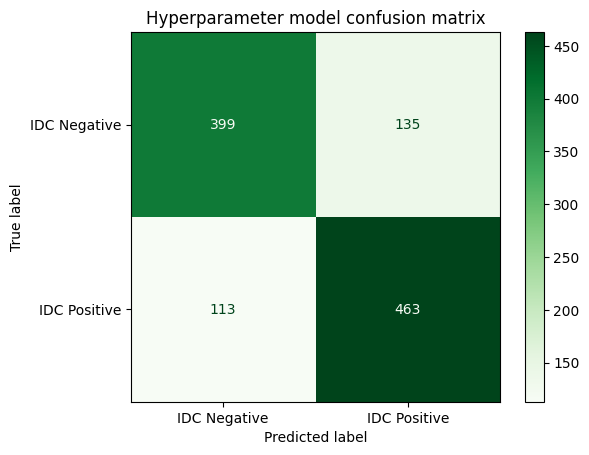

In [ ]:
# Compute the confusion matrix.

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# If probability is higer than 0.5 then its class 1 , otherwise class 0
y_pred_binary_hyperparameter = (y_pred_hyperparameter > 0.5).astype(int)
cm_hyperparameter = confusion_matrix(y_unseen_labels, y_pred_binary_hyperparameter)

print("Hyperparameter model confusion matrix:")
print(cm_hyperparameter)

# Plot confusion matrix
display = ConfusionMatrixDisplay(confusion_matrix = cm_hyperparameter, display_labels = ['IDC Negative', 'IDC Positive'])
display.plot(cmap = 'Greens')
plt.title('Hyperparameter model confusion matrix')
plt.show()



X_flattened_train_images (17748, 7500)
X_flattened_test_images (1110, 7500)
convergence after 5397 epochs took 16416 seconds
Logistic model confusion matrix:
[[346 188]
 [215 361]]


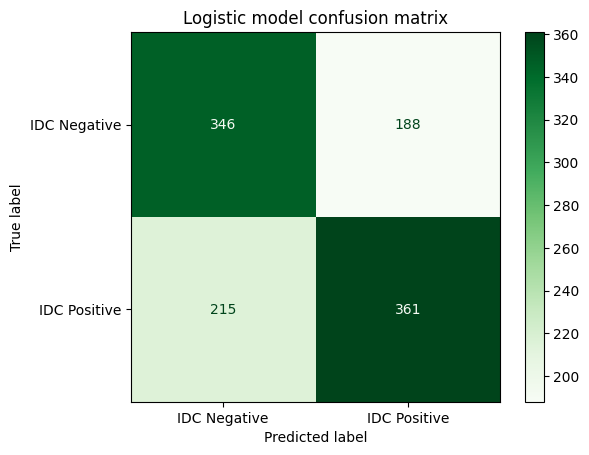

In [ ]:
# Create logistic model to train

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prepare dataset
X_logistic_train_images = X_combined_images
y_logistic_train_labels = y_combined_labels

X_logistic_test_images = X_unseen_images
y_logistic_test_labels = y_unseen_labels

# Normalise data or flatten data for pass to logistic regression
X_flattened_train_images = X_logistic_train_images.reshape(X_logistic_train_images.shape[0], -1)
X_flattened_test_images = X_logistic_test_images.reshape(X_logistic_test_images.shape[0], -1)

# Verify datset
print('X_flattened_train_images', X_flattened_train_images.shape)
print('X_flattened_test_images', X_flattened_test_images.shape)

# Train model
logistic_model = LogisticRegression(max_iter = 10000, solver='saga', verbose=1)
logistic_model.fit(X_flattened_train_images,y_logistic_train_labels)

# logistic model prediction
y_pred_logistic = logistic_model.predict(X_flattened_test_images)


# 3h 57m
# Compute the confusion matrix fro logistic regression.

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# If probability is higer than 0.5 then its class 1 , otherwise class 0
y_pred_binary_logistic = (y_pred_logistic > 0.5).astype(int)
confusion_matrix_logistic = confusion_matrix(y_unseen_labels, y_pred_binary_logistic)

print("Logistic model confusion matrix:")
print(confusion_matrix_logistic)

# Plot confusion matrix
display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_logistic, display_labels = ['IDC Negative', 'IDC Positive'])
display.plot(cmap = 'Greens')
plt.title('Logistic model confusion matrix')
plt.show()


# Evaluation and comparison.

## Initial models.

### Loss:
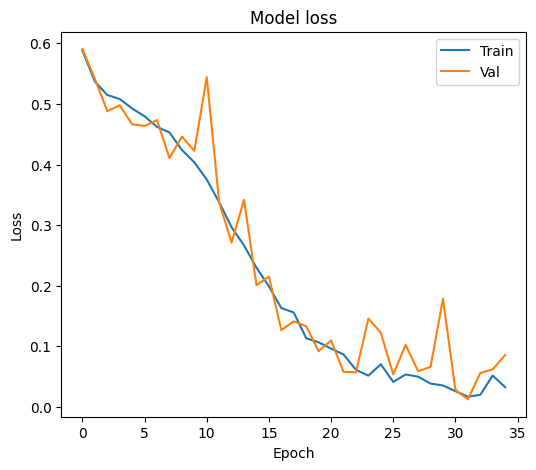

The training displays a rapid decrease up to the 20th epoch and then has a steady decrement pattern to 35 with small fluctuations and stopped. The validation decreased with noticeable fluctuations, especially in 10, around 13, 23 and 29. The gap between validation and training is small, which explains a minimal overfitting. The model demonstrated an effective learning curve.

### Accuracy:
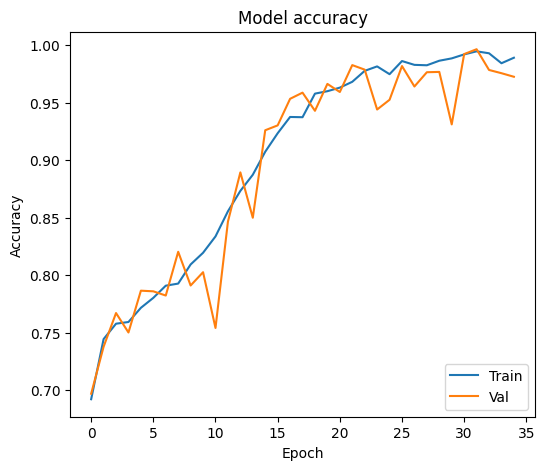

The training shows a rapid increment pattern up to the 20th epoch and steady increment to 35 and achieved near perfect accuracy when it was close to 35. The validation also experienced an overall rapid increment with noticeable fluctuations. There is a huge drop in validation at 10, 23 and 29. Overall validation accuracy takes lower position curve compared to the training which means it has minimum overfitting.

### ROC AUC:
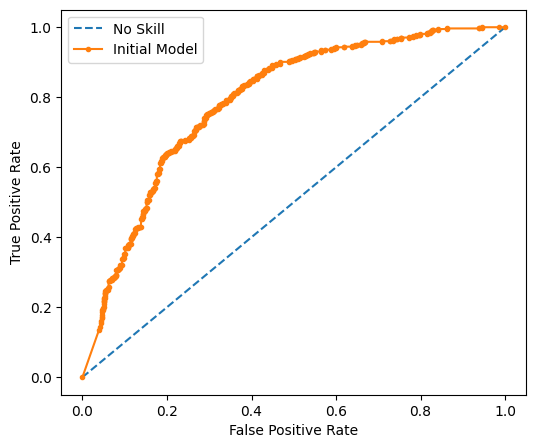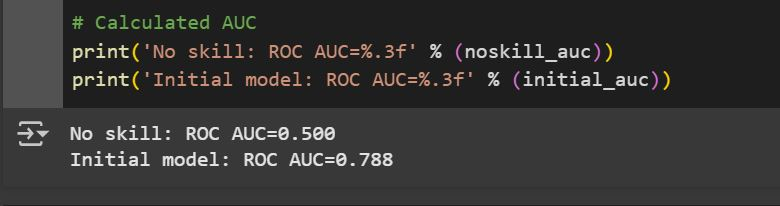

ROC AUC score is 0.788 which means the modal can effectively classify two classes compared to no skill baseline and indicates the model correctly ranked positive data higher than negative data in over 78% of cases. The model's curve indicates a good classification ability and maintained a high true positive rate while having low false positive.


### Confusion matrix:
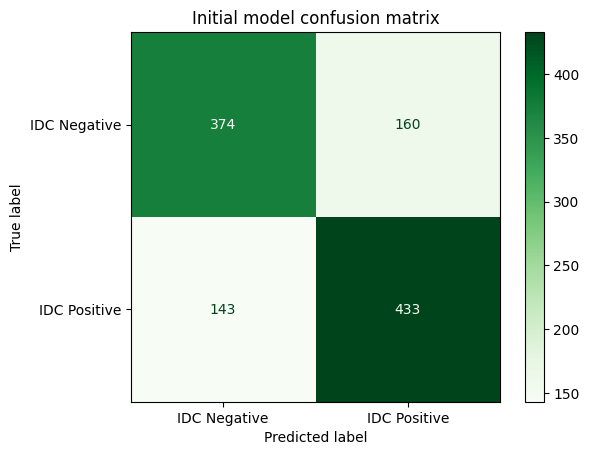

Tested to unseen data and true positive (TP): 433, true negative (TN): 374, false positive (FP): 160, false negative (FN): 143. The overall accuracy is 72.7% which demonstrates a balance perform, and precision is 73% which indicates the quality of the positive prediction. Sensitivity, the true positive rate, is 75.1%. The F1 score got 74% which explained that the model has ability to identify TP while maintaining a low FP rate. But FP and FN are higher when compared to the true values.



## Hyperparameters

### Hyperparameters best result:



* 'conv2d_1_filters':64

* 'conv2d_1_activation':'relu'

* 'conv2d_2_filters':32

* 'conv2d_2_activation':'relu'

* 'conv2d_3_filters':128

* 'conv2d_3_activation':'relu'

* 'dense_1_units':384

* 'dense_1_activation':'sigmoid'

* 'learning_rate':0.001

* 'optimizer':'adam'

* 'batch_size':32

* 'tuner/epochs':10

* 'tuner/initial_epoch':4

## Hyperparameter model’s loss and accuracy.

### Loss:
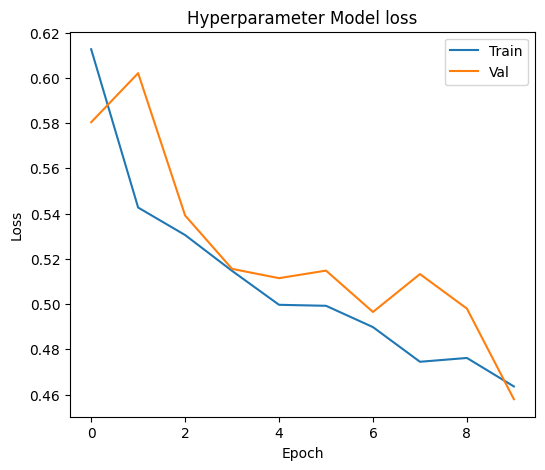

Compared to the initial model, the training follows the same pattern with rapid decrement within 10 epochs. Validation has less fluctuation and does not cross the training. There are spikes at 1 and 7 epochs in validation. Gap between training and validation curve is small and indicates less overfitting and shows an effective learning with hyperparameters than the initial model.

### Accuracy:
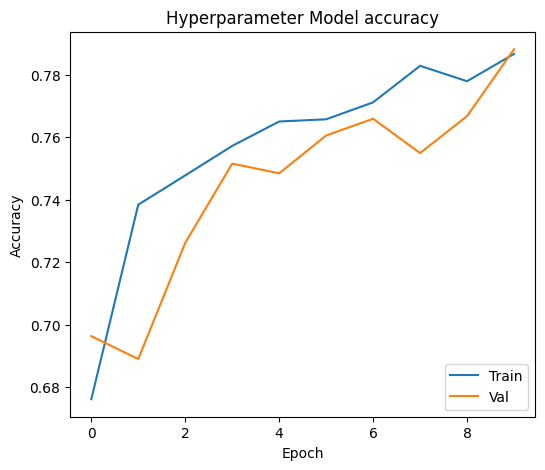

Both curves are rapidly increased. But hyperparameter model’s accuracy is not achieved near perfect level same as the initial model and stopped at 0.78. Validation does not fluctuate much but has major drop downs at 1, 4 and 7 epochs.

### ROC AUC:
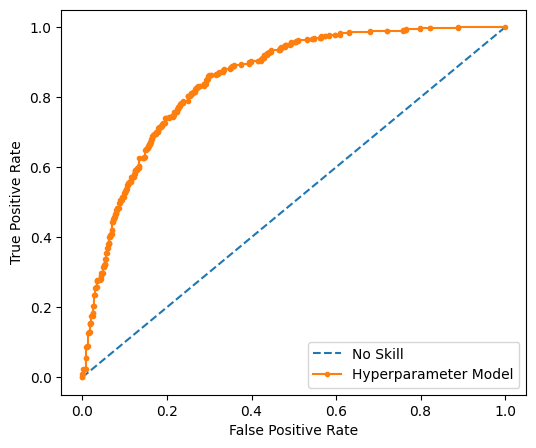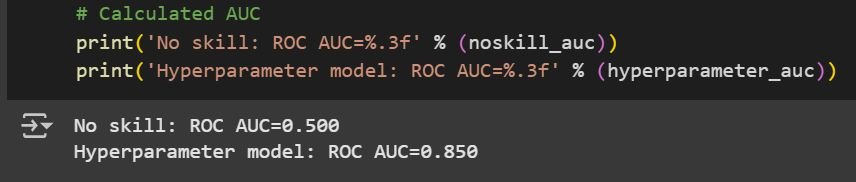

ROC AUC score is 0.850 which is 0.062 greater than the initial model. The model correctly ranked positive data higher than negative data in over 85% of cases. The TP rate is high, and the FP rate is low.

### Confusion matrix for unseen data:
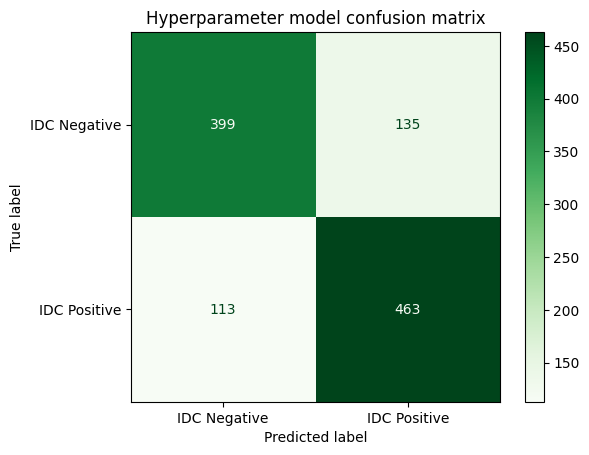
### Logistic Regression for unseen data:
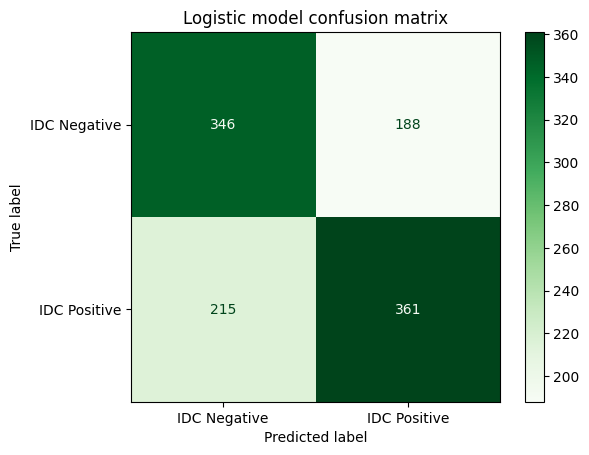



# Comparison
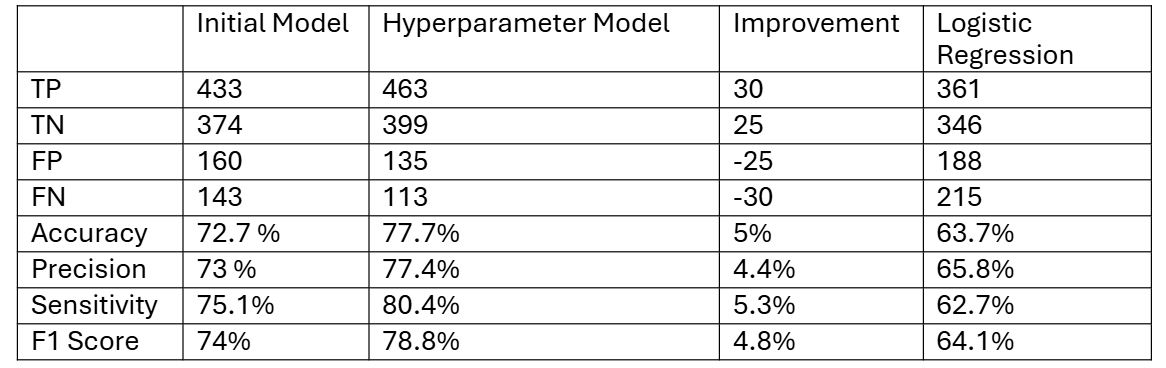

Hyperparameter model able to classify 30 TP (IDC 1), 25 TN (IDC 0) more than the initial model and decreased its FP and FN by 25 and 30, respectively and have the best accuracy, which is 77.7%, precision with 77.4%, sensitivity with 80.4% and F1 score with 78.8%. Overall, with each matrix, the hyperparameter model gained approximately 5% than the initial model which indicates that hyperparameters can improve initial model significantly. Logistic regression performed poorly compared to both other models and nearly 15% lower with each matrix than hyperparameter model.

# Conclusion.

CNN used to create models from scratch to gain advantages and the hyperparameter tuned to create the best model and achieved approximately 5% significant improvement compared to the initial model. The initial model took 47m to complete with 35 epoch when hyperparameter took 16m 43s with 10 epochs which shows that efficiency and accuracy are high with a lower execution time. Logistic regression is lower by around 15% against hyperparameter model which indicates not suitable for medium or large data set and took nearly 4 hours.

### Hyperparameter model:

Strength:

* CNN architectures are configurable and flexible for tuning.

* Lower execution time.

* Suitable for large dataset.



Limitations:

* Need knowledge and experience for implementation.

* Complex architecture.  



# References:

* Goodfellow, I., Bengio, Y. and Courville, A. (2016) Deep learning. Cambridge, MA: MIT Press.

* Moudden, T.E. and Amnai, M. (2023). Building an efficient convolution neural network from scratch: A case study on detecting and localizing slums. Scientific African, 20, p.e01612. doi:https://doi.org/10.1016/j.sciaf.2023.e01612.

* Naz Dündar, Ali Seydi Keçeli, Kaya, A. and Sever, H. (2024). A shallow 3D convolutional neural network for violence detection in videos. Egyptian Informatics Journal , 26, pp.100455–100455. doi:https://doi.org/10.1016/j.eij.2024.100455.

* Park, J., An, G., Lee, B.-N. and Seo, H. (2025). Real-time CNN-based object detection of prohibited items for X-ray security screening. Radiation Physics and Chemistry, [online] pp.112681–112681. doi:https://doi.org/10.1016/j.radphyschem.2025.112681

* Raschka, S. and Mirjalili, V. (2019) Python machine learning: Machine learning and deep learning with Python, scikit-learn, and TensorFlow 2. 3rd ed. Birmingham: Packt Publishing.

* Scikit-learn (2025) Logistic regression: Available at: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression (Accessed:02 May 2025).

* Suh, K.-S., Min, B.-I., Yang, B.-M., Kim, S., Park, K. and Kim, J. (2022). Machine learning method using camera image patterns for predictions of particulate matter concentrations. Atmospheric Pollution Research,  13, p.101325. https://doi.org/10.1016/j.apr.2022.101325

* Tensorflow (2010) tf.keras.optimizers.Adam: Available at: https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/keras/optimizers/Adam (Accessed:02 May 2025).